# Machine Learning Methods for Data Streams
## Project: Concept Drift Detection in Polarized News Streams

In [1]:
import requests
import trafilatura
import json
import time
from datetime import datetime
from dateutil.relativedelta import relativedelta
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
from collections import defaultdict

from river import compose
from river import feature_extraction
from river import naive_bayes
from river import metrics
from river import drift
from river import utils

### 2. Baseline prediction and concept drift detection

Predicting the political leaning of news articles (left, right) based on their content using a Naive Bayes classifier and TF-IDF vectorization.

Detect
 and detecting potential concept drift in the data stream using the ADWIN algorithm.

### Processing data

First schema: under-sampling the majority class to balance the dataset, then sorting chronologically by timestamp. 

In [2]:
def process_and_balance_jsonl(input_data):
    parsed_data = []
    for line in input_data:
        if line.strip(): 
            obj = json.loads(line)
            parsed_data.append({
                "timestamp": obj["timestamp"],
                "label": obj["label"],
                "text": obj["text"]
            })

    class_0 = [item for item in parsed_data if item["label"] == 0]
    class_1 = [item for item in parsed_data if item["label"] == 1]

    min_count = min(len(class_0), len(class_1))
    
    if min_count == 0:
        return []

    balanced_class_0 = random.sample(class_0, min_count)
    balanced_class_1 = random.sample(class_1, min_count)

    balanced_data = balanced_class_0 + balanced_class_1

    balanced_data.sort(key=lambda x: x["timestamp"])

    return balanced_data

Second schema: extracting max one article per day pe class, produces possibly unbalanced dataset, but preserves temporal distribution of classes.

In [3]:
def extract_max_one_per_class_per_day(input_data):
    grouped_data = defaultdict(lambda: {0: [], 1: []})

    for line in input_data:
        if line.strip():
            obj = json.loads(line)
            timestamp = obj["timestamp"]
            label = obj["label"]
            
            date_only = timestamp[:10] 
            
            extracted_obj = {
                "timestamp": timestamp,
                "label": label,
                "text": obj.get("text", "")
            }
            
            grouped_data[date_only][label].append(extracted_obj)

    selected_data = []
    
    for date, classes in grouped_data.items():
        class_0_items = classes[0]
        class_1_items = classes[1]
        
        if class_0_items:
            selected_data.append(random.choice(class_0_items))
            
        if class_1_items:
            selected_data.append(random.choice(class_1_items))

    selected_data.sort(key=lambda x: x["timestamp"])

    return selected_data


In [4]:
def plot_results(dates, accuracies, drifts_dates, header):
    plt.figure(figsize=(14, 7))
    
    plt.plot(dates, accuracies, label='Rolling Accuracy (n=50)', color='blue', linewidth=2.5)
    
    tz = dates[0].tzinfo
    election_day = datetime(2024, 11, 5, tzinfo=tz)
    plt.axvline(x=election_day, color='purple', linestyle='-', linewidth=2, label='Election (05.11.2024)')
    inauguration_day = datetime(2025, 1, 20, tzinfo=tz)
    plt.axvline(x=inauguration_day, color='orange', linestyle='-', linewidth=2, label='Inauguration (20.01.2025)')

    for i, d in enumerate(drifts_dates):
        label = 'Concept Drift (ADWIN)' if i == 0 else ""
        plt.axvline(x=d, color='red', linestyle='--', alpha=0.8, linewidth=1.5, label=label)


    plt.title(f'{header}', fontsize=16, fontweight='bold')
    plt.xlabel('Date of publication', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.ylim(0.0, 1.05)
    
    plt.legend(loc='lower left', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [5]:
def run_experiment(data_stream):
    
    model = compose.Pipeline(
        ('vectorizer', feature_extraction.TFIDF(lowercase=True)),
        ('classifier', naive_bayes.MultinomialNB())
    )
    
    metric = utils.Rolling(metrics.Accuracy(), window_size=50) 
    
    drift_detector = drift.ADWIN(delta=0.02) 
    
    dates = []
    accuracies = []
    drifts_dates = []
    
    latest_seen_date = datetime.fromisoformat(data_stream[0]['timestamp'].replace('Z', '+00:00'))
    
    for i, record in enumerate(data_stream):
        text = record['text']
        label = record['label'] 
        
        current_date = datetime.fromisoformat(record['timestamp'].replace('Z', '+00:00'))
        if current_date > latest_seen_date:
            latest_seen_date = current_date
            
        y_pred = model.predict_one(text)
        
        if y_pred is not None:
            metric.update(label, y_pred)
            
            error = 0 if y_pred == label else 1
            drift_detector.update(error)
            
            dates.append(latest_seen_date)
            accuracies.append(metric.get())
            
            if drift_detector.drift_detected:
                print(f"Detected Concept Drift on {latest_seen_date.strftime('%Y-%m-%d')}")
                drifts_dates.append(latest_seen_date)
        
        model.learn_one(text, label)
        
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1} articles.")

    return dates, accuracies, drifts_dates

In [6]:
FILE_PATH = "data/polarized_combined1.jsonl" 
with open(FILE_PATH, 'r', encoding='utf-8') as f:
    wiersze = f.readlines()

### Experiment with schema 1

Processed 100 articles.
Detected Concept Drift on 2024-02-06
Processed 200 articles.
Detected Concept Drift on 2024-03-01
Processed 300 articles.
Processed 400 articles.
Processed 500 articles.
Processed 600 articles.
Processed 700 articles.
Processed 800 articles.
Processed 900 articles.
Detected Concept Drift on 2024-07-23
Processed 1000 articles.
Processed 1100 articles.
Processed 1200 articles.
Processed 1300 articles.
Processed 1400 articles.
Processed 1500 articles.
Processed 1600 articles.
Processed 1700 articles.
Detected Concept Drift on 2025-01-01
Processed 1800 articles.
Processed 1900 articles.
Processed 2000 articles.
Processed 2100 articles.
Processed 2200 articles.
Processed 2300 articles.
Processed 2400 articles.
Processed 2500 articles.
Processed 2600 articles.
Processed 2700 articles.
Processed 2800 articles.
Processed 2900 articles.
Processed 3000 articles.
Processed 3100 articles.
Processed 3200 articles.
Processed 3300 articles.
Processed 3400 articles.
Processed 3

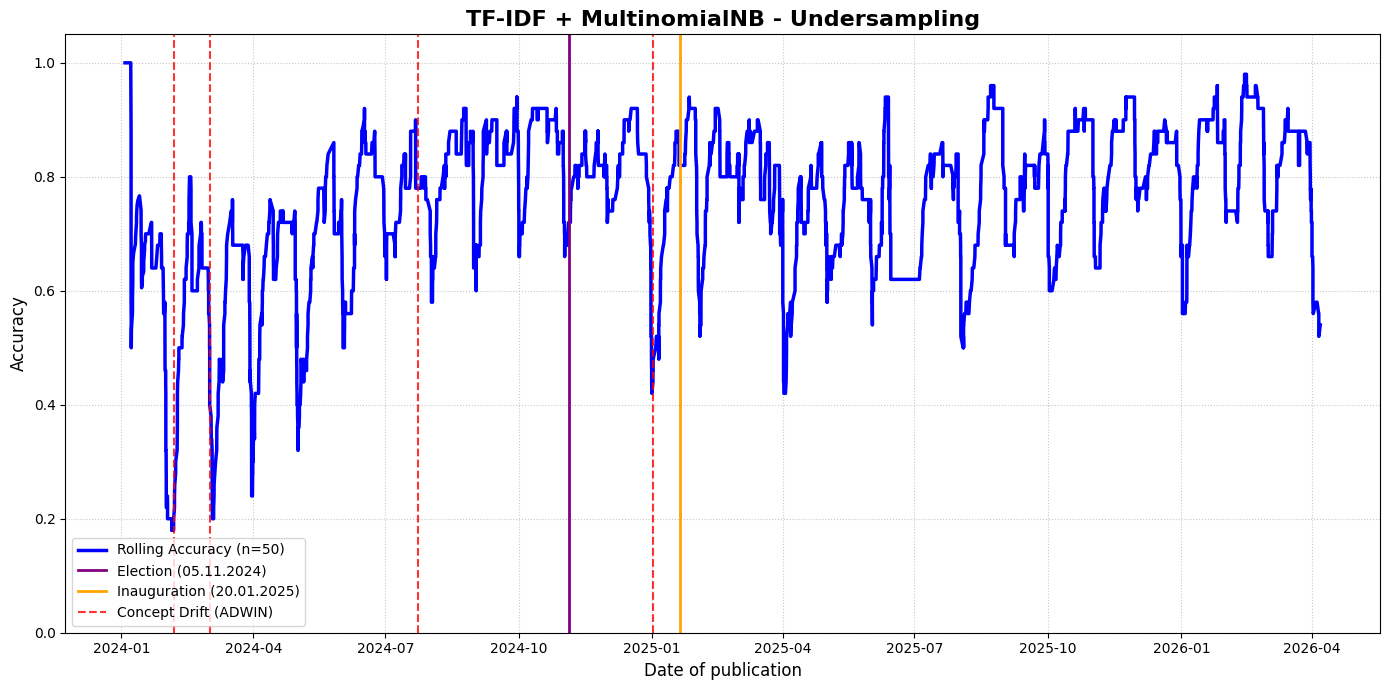

In [7]:
sorted_stream1 = process_and_balance_jsonl(wiersze)
steps, acc, drifts = run_experiment(sorted_stream1)
header = "TF-IDF + MultinomialNB - Undersampling"
plot_results(steps, acc, drifts, header)

### Experiment with schema 2

Processed 100 articles.
Processed 200 articles.
Processed 300 articles.
Processed 400 articles.
Processed 500 articles.
Processed 600 articles.
Processed 700 articles.
Processed 800 articles.


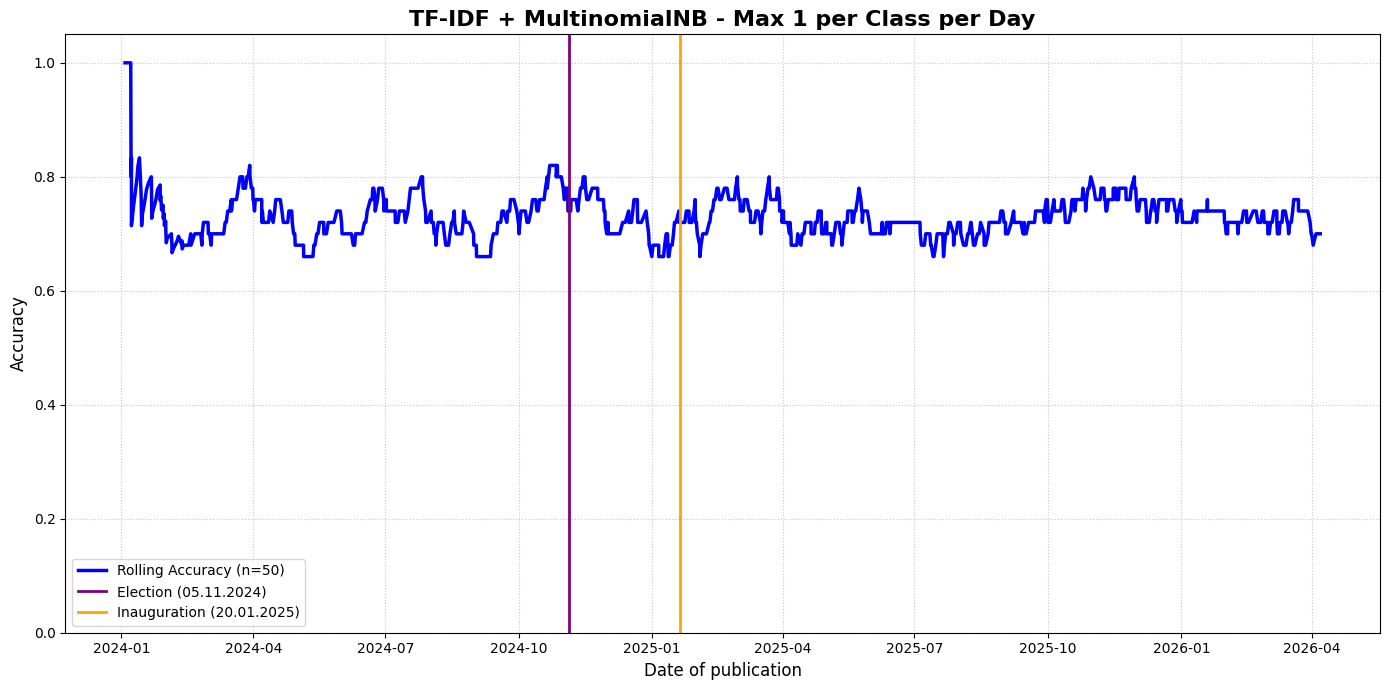

In [8]:
sorted_stream2 = extract_max_one_per_class_per_day(wiersze)
steps2, acc2, drifts2 = run_experiment(sorted_stream2)
header2 = "TF-IDF + MultinomialNB - Max 1 per Class per Day"
plot_results(steps2, acc2, drifts2, header2)